In [1]:
from fastbook import *
from fastai.vision.widgets import *
from fastai.vision.all import get_image_files

In [2]:
path = Path('./data/')
fns = get_image_files(path)

In [3]:
failed = verify_images(fns)
failed

[]

In [4]:
pots = DataBlock(
    blocks=(ImageBlock, CategoryBlock), 
    get_items=get_image_files, 
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=Resize(128))

In [5]:
dls = pots.dataloaders(path)

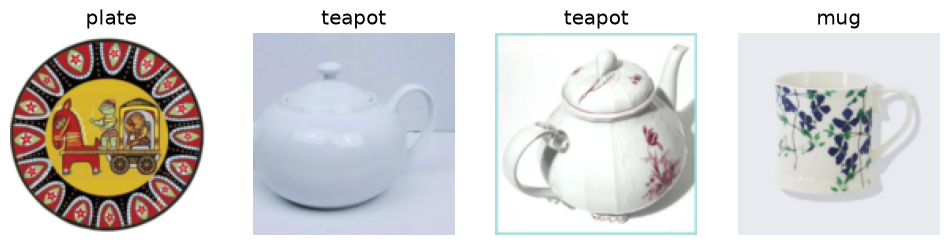

In [6]:
dls.valid.show_batch(max_n=4, nrows=1)

In [7]:
# pots = pots.new(item_tfms=Resize(128), batch_tfms=aug_transforms(mult=2))
# dls = pots.dataloaders(path)
# dls.train.show_batch(max_n=8, nrows=2, unique=True)

In [8]:
pots = pots.new(
    item_tfms=RandomResizedCrop(224, min_scale=0.5),
    batch_tfms=aug_transforms())
dls = pots.dataloaders(path)

In [9]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(4)

epoch,train_loss,valid_loss,error_rate,time
0,1.108082,0.447958,0.145691,00:40


epoch,train_loss,valid_loss,error_rate,time
0,0.572934,0.350964,0.108493,00:50
1,0.439973,0.301576,0.097334,00:50
2,0.327044,0.270901,0.085555,00:50
3,0.259582,0.267524,0.081835,00:50


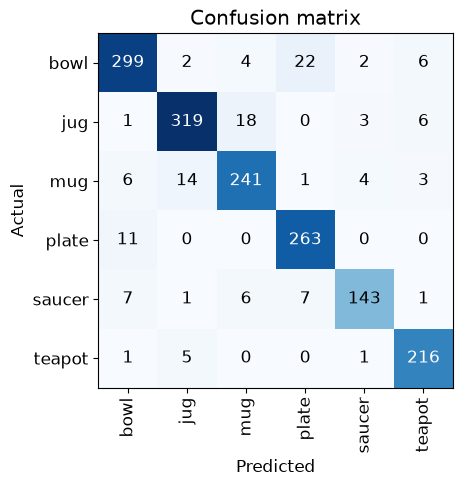

In [10]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()

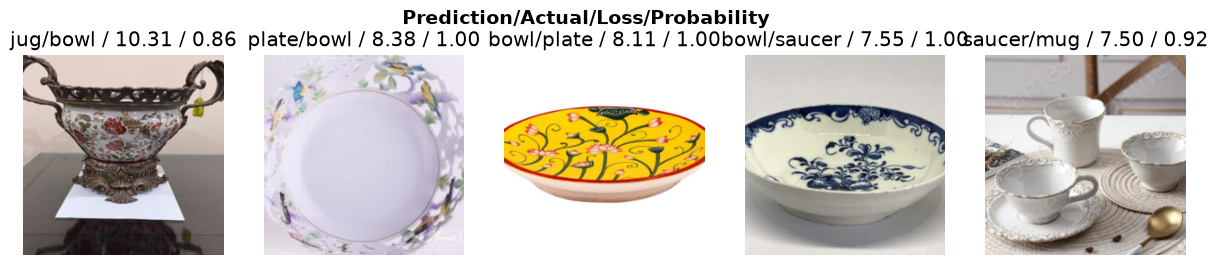

In [11]:
interp.plot_top_losses(5, nrows=1)

In [12]:
cleaner = ImageClassifierCleaner(learn)
cleaner

In [13]:
learn.export()

In [14]:
path_export = Path()
path_export.ls(file_exts='.pkl')

[Path('export.pkl')]

In [15]:
learn_inf = load_learner(path_export/'export.pkl')

/Users/docam/Documents/Projects/potteryClassifier/.venv/lib/python3.13/site-packages/fastai/learner.py:456: UserWarning: load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.
If you only need to load model weights and optimizer state, use the safe `Learner.load` instead.
  warn("load_learner` uses Python's insecure pickle module, which can execute malicious arbitrary code when loading. Only load files you trust.\nIf you only need to load model weights and optimizer state, use the safe `Learner.load` instead.")


In [16]:
learn_inf.predict('./data/teapot/20240205-225020-419508.jpg')

('teapot',
 tensor(5),
 tensor([4.2554e-08, 4.5228e-03, 4.7819e-04, 3.6648e-06, 3.1297e-05, 9.9496e-01]))

In [17]:
learn_inf.dls.vocab

['bowl', 'jug', 'mug', 'plate', 'saucer', 'teapot']

In [18]:
btn_upload = widgets.FileUpload()
btn_upload

FileUpload(value={}, description='Upload')

In [20]:
img = PILImage.create(btn_upload.data[-1])

In [21]:
out_pl = widgets.Output()
out_pl.clear_output()
with out_pl: display(img.to_thumb(128,128))
out_pl

Output()

In [22]:
pred,pred_idx,probs = learn_inf.predict(img)

In [23]:
lbl_pred = widgets.Label()
lbl_pred.value = f'Prediction: {pred}; Probability: {probs[pred_idx]:.04f}'
lbl_pred

Label(value='Prediction: mug; Probability: 0.9945')

In [24]:
btn_run = widgets.Button(description='Classify')
btn_run

Button(description='Classify', style=ButtonStyle())

In [25]:
def on_click_classify(change):
    img = PILImage.create(btn_upload.data[-1])
    out_pl.clear_output()
    with out_pl: display(img.to_thumb(128,128))
    pred,pred_idx,probs = learn_inf.predict(img)
    lbl_pred.value = f'Prediction: {pred}; Probability: {probs[pred_idx]:.04f}'

btn_run.on_click(on_click_classify)

In [26]:
btn_upload = widgets.FileUpload()
VBox([widgets.Label('Select your bear!'), 
      btn_upload, btn_run, out_pl, lbl_pred])